Creating input data from observations

In [1]:
import pandas as pd
import numpy as np

observations = pd.DataFrame(pd.read_pickle('/kaggle/input/datasets/maanav0114/harps-n-dataset/observations.pkl'))
pos_stars = list(set(observations[observations['has_exoplanets'] == 1]['star_name']))
neg_stars = list(set(observations[observations['has_exoplanets'] == 0]['star_name']))

# Sinusoidal positional encoding for BJD
NUM_FREQS = 8
min_period = 1.0
max_period = 7300.0
periods = np.logspace(np.log10(min_period), np.log10(max_period), NUM_FREQS)
freqs = 2.0 * np.pi / periods

def bjd_positional_encoding(bjd, ref_bjd):
    dt = bjd - ref_bjd
    encoding = []
    for f in freqs:
        encoding.append(np.sin(f * dt))
        encoding.append(np.cos(f * dt))
    return encoding

pos_inputs = []
neg_inputs = []

for star in pos_stars:
    star_obs = observations[observations['star_name'] == star].sort_values('bjd')
    ref_bjd = star_obs['bjd'].iloc[0]

    rows = []
    for idx in range(len(star_obs)):
        row = list(star_obs.iloc[idx])
        # Columns at this point: star_name, bjd, rv, rv_err, exposure_time, RHKp, Halpha, has_exoplanets, rv_centered
        # Indices:              0          1    2   3       4              5      6       7               8
        bjd = row[1]
        rv_centered = row[8]
        rv_err = row[3]
        exposure_time = row[4]
        rhkp = row[5]
        halpha = row[6]

        pos_enc = bjd_positional_encoding(bjd, ref_bjd)

        features = [rv_centered, rv_err, exposure_time, rhkp, halpha] + pos_enc
        rows.append(features)

    pos_inputs.append(np.array(rows))

for star in neg_stars:
    star_obs = observations[observations['star_name'] == star].sort_values('bjd')
    ref_bjd = star_obs['bjd'].iloc[0]

    rows = []
    for idx in range(len(star_obs)):
        row = list(star_obs.iloc[idx])
        bjd = row[1]
        rv_centered = row[8]
        rv_err = row[3]
        exposure_time = row[4]
        rhkp = row[5]
        halpha = row[6]

        pos_enc = bjd_positional_encoding(bjd, ref_bjd)

        features = [rv_centered, rv_err, exposure_time, rhkp, halpha] + pos_enc
        rows.append(features)

    neg_inputs.append(np.array(rows))

print(f"Positive stars: {len(pos_inputs)}, total observations: {sum(len(x) for x in pos_inputs)}")
print(f"Negative stars: {len(neg_inputs)}, total observations: {sum(len(x) for x in neg_inputs)}")
print(f"Feature dimension per observation: {pos_inputs[0].shape[1]}")

Positive stars: 413, total observations: 46533
Negative stars: 1774, total observations: 189034
Feature dimension per observation: 21


Creating Data Splits

In [2]:
import torch
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
import random

def seed_everything(seed):
    import random
    import torch
    import numpy as np

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True

seed = 42
seed_everything(seed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ── Split FIRST (on raw features) ──
train_pos, temp_pos = train_test_split(pos_inputs, test_size = 0.4, random_state = seed)
val_pos, test_pos = train_test_split(temp_pos, test_size = 0.5, random_state = seed)

train_neg, temp_neg = train_test_split(neg_inputs, test_size = 0.4, random_state = seed)
val_neg, test_neg = train_test_split(temp_neg, test_size = 0.5, random_state = seed)

# ── Standardize SECOND using TRAINING stats only ──
train_all = np.concatenate(train_pos + train_neg, axis=0)
feat_mean = train_all.mean(axis=0)
feat_std = train_all.std(axis=0)
feat_std = np.clip(feat_std, 1e-8, None)

print(f"Training set feature means (first 3): {feat_mean[:3]}")
print(f"Training set feature stds  (first 3): {feat_std[:3]}")

train_pos = [(star - feat_mean) / feat_std for star in train_pos]
train_neg = [(star - feat_mean) / feat_std for star in train_neg]
val_pos   = [(star - feat_mean) / feat_std for star in val_pos]
val_neg   = [(star - feat_mean) / feat_std for star in val_neg]
test_pos  = [(star - feat_mean) / feat_std for star in test_pos]
test_neg  = [(star - feat_mean) / feat_std for star in test_neg]

# ── Truncate long sequences to avoid OOM ──
MAX_SEQ_LEN = 100

def truncate_star(star, max_len=MAX_SEQ_LEN):
    if len(star) > max_len:
        return star[:max_len]
    return star

truncated_counts = []
for star_list in [train_pos, train_neg, val_pos, val_neg, test_pos, test_neg]:
    for i in range(len(star_list)):
        original_len = len(star_list[i])
        star_list[i] = truncate_star(star_list[i], MAX_SEQ_LEN)
        if original_len > MAX_SEQ_LEN:
            truncated_counts.append(original_len)

if truncated_counts:
    print(f"Truncated {len(truncated_counts)} stars (original lengths: {min(truncated_counts)}-{max(truncated_counts)})")
else:
    print("No stars needed truncation")

all_lens = [len(x) for x in train_pos + train_neg + val_pos + val_neg + test_pos + test_neg]
print(f"Sequence lengths after truncation: min={min(all_lens)}, max={max(all_lens)}, median={int(np.median(all_lens))}")

train_data = train_pos + train_neg
val_data = val_pos + val_neg
test_data = test_pos + test_neg

Using device: cuda
Training set feature means (first 3): [-6.65848736e-02  1.80053151e+00  3.15289969e+02]
Training set feature stds  (first 3): [1337.7309127     3.58246899  375.26186443]
Truncated 418 stars (original lengths: 101-11469)
Sequence lengths after truncation: min=18, max=100, median=41


In [3]:
class StarDataset(Dataset):
    def __init__(self, stars, labels):
        self.data = stars
        self.labels = labels

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        star = torch.tensor(self.data[idx], dtype=torch.float32)
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return star, label

def collate_stars(batch):
    """Custom collate: pad variable-length star sequences to the longest in the batch.

    Returns:
        padded:  (B, max_seq_len, 19) — feature tensors, zero-padded
        mask:    (B, max_seq_len)     — True where real data is, False where padding is
        labels:  (B,)                 — labels
    """
    stars, labels = zip(*batch)

    # Find the longest sequence in this batch
    max_len = max(s.shape[0] for s in stars)

    padded = []
    mask = []

    for star in stars:
        seq_len = star.shape[0]
        pad_len = max_len - seq_len
        feat_dim = star.shape[1]  # 19

        # Pad with zeros along the time dimension
        if pad_len > 0:
            padding = torch.zeros(pad_len, feat_dim)
            padded_star = torch.cat([star, padding], dim=0)
        else:
            padded_star = star

        # Mask: True = real observation, False = padding
        star_mask = torch.cat([
            torch.ones(seq_len),
            torch.zeros(pad_len)
        ])

        padded.append(padded_star)
        mask.append(star_mask)

    padded = torch.stack(padded)     # (B, max_seq_len, 19)
    mask = torch.stack(mask)         # (B, max_seq_len)
    labels = torch.stack(labels)     # (B,)

    return padded, mask, labels

train_labels = [1 for i in range(len(train_pos))] + [0 for i in range(len(train_neg))]
val_labels = [1 for i in range(len(val_pos))] + [0 for i in range(len(val_neg))]
test_labels = [1 for i in range(len(test_pos))] + [0 for i in range(len(test_neg))]

train_dataset = StarDataset(train_data, train_labels)
val_dataset = StarDataset(val_data, val_labels)
test_dataset = StarDataset(test_data, test_labels)

In [4]:
batch_size = 32

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=False,
    collate_fn=collate_stars,    # <-- the key addition
    pin_memory=True if device.type == 'cuda' else False
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    shuffle=False,
    drop_last=False,
    collate_fn=collate_stars,
    pin_memory=True if device.type == 'cuda' else False
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False,
    drop_last=False,
    collate_fn=collate_stars,
    pin_memory=True if device.type == 'cuda' else False
)

Creating Model

In [5]:
import torch.nn as nn
import torch.nn.functional as F

class AttentionPool(nn.Module):
    """Learn which observations matter most for the classification."""
    def __init__(self, d_model):
        super().__init__()
        self.attention = nn.Linear(d_model, 1)

    def forward(self, x, mask):
        scores = self.attention(x).squeeze(-1)  # (B, seq_len)
        scores = scores.masked_fill(~mask.bool(), float('-inf'))
        weights = F.softmax(scores, dim=1)  # (B, seq_len)
        pooled = (x * weights.unsqueeze(-1)).sum(dim=1)  # (B, d_model)
        return pooled

class ExoplanetTransformer(nn.Module):
    def __init__(self, feat_dim=21, d_model=48, nhead=4, num_layers=1, dim_feedforward=96, dropout=0.3):
        super().__init__()

        self.input_proj = nn.Linear(feat_dim, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.pool = AttentionPool(d_model)

        self.classifier = nn.Sequential(
            nn.Linear(d_model, 16),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(16, 1),
        )

    def forward(self, x, mask):
        x = self.input_proj(x)
        src_key_padding_mask = ~mask.bool()
        x = self.transformer(x, src_key_padding_mask=src_key_padding_mask)
        x = self.pool(x, mask)
        out = self.classifier(x).squeeze(-1)
        return out

model = ExoplanetTransformer().to(device)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

ExoplanetTransformer(
  (input_proj): Linear(in_features=21, out_features=48, bias=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0): TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=48, out_features=48, bias=True)
        )
        (linear1): Linear(in_features=48, out_features=96, bias=True)
        (dropout): Dropout(p=0.3, inplace=False)
        (linear2): Linear(in_features=96, out_features=48, bias=True)
        (norm1): LayerNorm((48,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((48,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.3, inplace=False)
        (dropout2): Dropout(p=0.3, inplace=False)
      )
    )
  )
  (pool): AttentionPool(
    (attention): Linear(in_features=48, out_features=1, bias=True)
  )
  (classifier): Sequential(
    (0): Linear(in_features=48, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout

Training model

In [6]:
from torch.optim import Adam
from torch.optim.lr_scheduler import LambdaLR
import math

# Milder pos_weight: sqrt ratio instead of raw ratio
n_pos = len(train_pos)
n_neg = len(train_neg)
pos_weight = torch.tensor([math.sqrt(n_neg / n_pos)]).to(device)
print(f"pos_weight = {pos_weight.item():.4f} (sqrt ratio, was {n_neg/n_pos:.4f})")
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = Adam(model.parameters(), lr=1e-3, weight_decay=5e-3)

# LR warmup: linear ramp for first 5 epochs, then cosine decay
warmup_epochs = 5
total_epochs = 100

def lr_lambda(epoch):
    if epoch < warmup_epochs:
        return (epoch + 1) / warmup_epochs
    else:
        progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
        return 0.5 * (1 + math.cos(math.pi * progress))

scheduler = LambdaLR(optimizer, lr_lambda)

train_losses = []
val_losses = []
train_accs = []
val_accs = []

best_val_loss = float('inf')
best_model_state = None
patience = 10
epochs_no_improve = 0
max_epochs = 100

for epoch in range(max_epochs):
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    for padded, mask, labels in train_loader:
        padded = padded.to(device)
        mask = mask.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(padded, mask)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss += loss.item() * padded.size(0)
        preds = (logits > 0).float()
        train_correct += (preds == labels).sum().item()
        train_total += padded.size(0)

    scheduler.step()

    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for padded, mask, labels in val_loader:
            padded = padded.to(device)
            mask = mask.to(device)
            labels = labels.to(device)

            logits = model(padded, mask)
            loss = criterion(logits, labels)

            val_loss += loss.item() * padded.size(0)
            preds = (logits > 0).float()
            val_correct += (preds == labels).sum().item()
            val_total += padded.size(0)

    epoch_train_loss = train_loss / train_total
    epoch_val_loss = val_loss / val_total
    train_acc = train_correct / train_total
    val_acc = val_correct / val_total
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        epochs_no_improve = 0
        marker = " ✓ best"
    else:
        epochs_no_improve += 1
        marker = ""

    print(f"Epoch {epoch+1:3d}/{max_epochs} | Train Loss: {epoch_train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {epoch_val_loss:.4f} Acc: {val_acc:.4f} | LR: {scheduler.get_last_lr()[0]:.6f}{marker}")

    if epochs_no_improve >= patience:
        print(f"\nEarly stopping at epoch {epoch+1} — val loss hasn't improved for {patience} epochs.")
        break

if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"Restored model from best checkpoint (val loss = {best_val_loss:.4f})")

pos_weight = 2.0755 (sqrt ratio, was 4.3077)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Epoch   1/100 | Train Loss: 0.8343 Acc: 0.4859 | Val Loss: 0.8059 Acc: 0.7922 | LR: 0.000400 ✓ best
Epoch   2/100 | Train Loss: 0.7730 Acc: 0.7956 | Val Loss: 0.7547 Acc: 0.8105 | LR: 0.000600 ✓ best
Epoch   3/100 | Train Loss: 0.7595 Acc: 0.8009 | Val Loss: 0.7478 Acc: 0.8105 | LR: 0.000800 ✓ best
Epoch   4/100 | Train Loss: 0.7449 Acc: 0.8032 | Val Loss: 0.7503 Acc: 0.8105 | LR: 0.001000
Epoch   5/100 | Train Loss: 0.7410 Acc: 0.8047 | Val Loss: 0.7416 Acc: 0.8128 | LR: 0.001000 ✓ best
Epoch   6/100 | Train Loss: 0.7493 Acc: 0.8040 | Val Loss: 0.7358 Acc: 0.8105 | LR: 0.001000 ✓ best
Epoch   7/100 | Train Loss: 0.7294 Acc: 0.8131 | Val Loss: 0.7306 Acc: 0.8128 | LR: 0.000999 ✓ best
Epoch   8/100 | Train Loss: 0.7323 Acc: 0.8116 | Val Loss: 0.7261 Acc: 0.8128 | LR: 0.000998 ✓ best
Epoch   9/100 | Train Loss: 0.7234 Acc: 0.8146 | Val Loss: 0.7177 Acc: 0.8082 | LR: 0.000996 ✓ best
Epoch  10/100 | Train Loss: 0.7199 Acc: 0.8009 | Val Loss: 0.7170 Acc: 0.8082 | LR: 0.000993 ✓ best
Epoch  

In [7]:
torch.save(model.state_dict(), "/kaggle/working/model.pth")

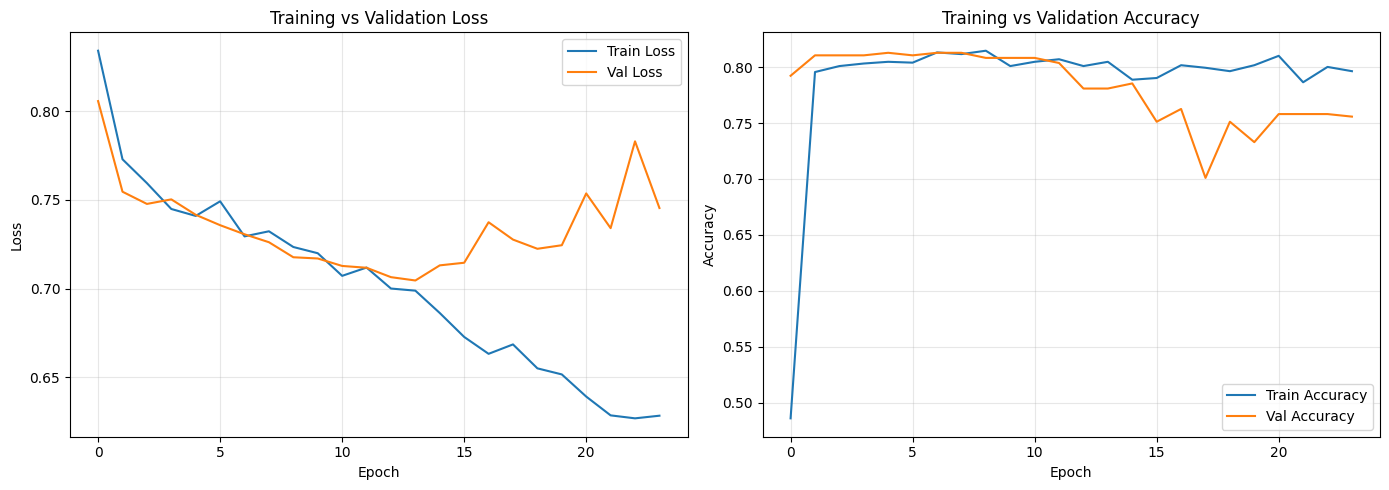

In [8]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
ax1.plot(train_losses, label='Train Loss', color='#1f77b4')
ax1.plot(val_losses, label='Val Loss', color='#ff7f0e')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training vs Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy plot
ax2.plot(train_accs, label='Train Accuracy', color='#1f77b4')
ax2.plot(val_accs, label='Val Accuracy', color='#ff7f0e')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training vs Validation Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Model Evaluation on Test Set

In [9]:
true_pos = 0
true_neg = 0
false_pos = 0
false_neg = 0


model.eval()
threshold = 0.5

with torch.no_grad():
    for stars, masks, labels in test_loader:
        stars = stars.to(device)
        masks = masks.to(device)
        labels = labels.to(device)

        logits = model.forward(stars, masks)
        preds = torch.sigmoid(logits)

        for idx in range(len(preds)):
            pred = preds[idx].item()
            label = labels[idx].item()
            if pred >= threshold: # Predicting Positive
                if label == 1:
                    true_pos += 1
                elif label == 0:
                    false_pos += 1

            elif pred < threshold: # Predicting Negative
                if label == 0:
                    true_neg += 1
                elif label == 1:
                    false_neg += 1

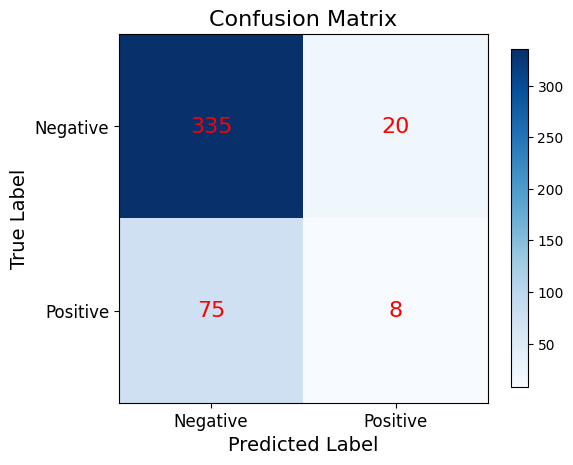

true_pos: 8
true_neg: 335
false_pos: 20
false_neg: 75


In [10]:
cm = np.array([[true_neg, false_pos],
                  [false_neg, true_pos]])
    
# Plot configuration
plt.figure(figsize=(6, 6))
plt.imshow(cm, cmap='Blues', interpolation='nearest')
plt.colorbar(shrink=0.6)

# Labels
classes = ['Negative', 'Positive']
plt.xticks([0, 1], classes, fontsize=12)
plt.yticks([0, 1], classes, fontsize=12)
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.title('Confusion Matrix', fontsize=16)

# Add value annotations
for i in range(2):
    for j in range(2):
        plt.text(j, i, f'{cm[i, j]}',
                    ha='center', va='center',
                    fontsize=16, color='red')

plt.tight_layout()
plt.show()



print(f"true_pos: {true_pos}")
print(f"true_neg: {true_neg}")
print(f"false_pos: {false_pos}")
print(f"false_neg: {false_neg}")

In [11]:
accuracy = (true_pos + true_neg) / (true_pos + true_neg + false_pos + false_neg)
precision = true_pos / (true_pos + false_pos)
recall = true_pos / (true_pos + false_neg)
f1 = (2 * precision * recall) / (precision + recall)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1: {f1}")

Accuracy: 0.7831050228310502
Precision: 0.2857142857142857
Recall: 0.0963855421686747
F1: 0.14414414414414417


In [12]:
import torch
import numpy as np
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

model.eval()
all_probs = []
all_labels = []

with torch.no_grad():
    for stars, masks, labels in test_loader:
        stars = stars.to(device)
        masks = masks.to(device)

        logits = model(stars, masks)
        probs = torch.sigmoid(logits)

        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

auc = roc_auc_score(all_labels, all_probs)
print(f"ROC-AUC: {auc:.4f}")

ROC-AUC: 0.6793


Best F1 threshold: 0.3717
  Precision: 0.3155
  Recall:    0.6386
  F1:        0.4223


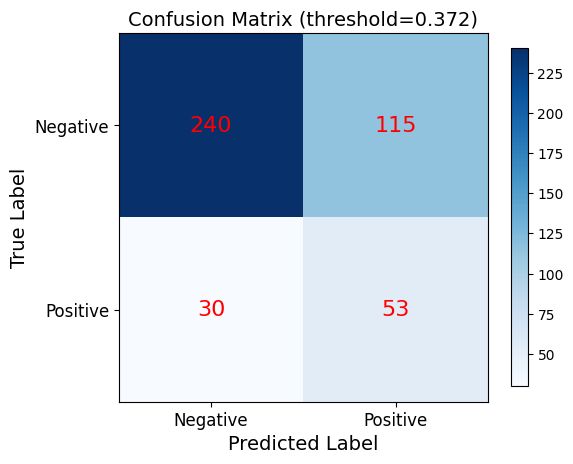

In [13]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precisions, recalls, thresholds = precision_recall_curve(all_labels, all_probs)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best F1 threshold: {best_threshold:.4f}")
print(f"  Precision: {precisions[best_idx]:.4f}")
print(f"  Recall:    {recalls[best_idx]:.4f}")
print(f"  F1:        {f1_scores[best_idx]:.4f}")

preds = (all_probs >= best_threshold).astype(int)
cm = confusion_matrix(all_labels, preds)

plt.figure(figsize=(6, 6))
plt.imshow(cm, cmap='Blues', interpolation='nearest')
plt.colorbar(shrink=0.6)

classes = ['Negative', 'Positive']
plt.xticks([0, 1], classes, fontsize=12)
plt.yticks([0, 1], classes, fontsize=12)
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.title(f'Confusion Matrix (threshold={best_threshold:.3f})', fontsize=14)

for i in range(2):
    for j in range(2):
        plt.text(j, i, f'{cm[i, j]}', ha='center', va='center', fontsize=16, color='red')

plt.tight_layout()
plt.show()

In [14]:
from sklearn.metrics import classification_report

print("=" * 60)
print("REPORT AT DEFAULT THRESHOLD (0.5)")
print("=" * 60)
preds_05 = (all_probs >= 0.5).astype(int)
print(classification_report(all_labels, preds_05, target_names=['No Planet', 'Planet']))

print("=" * 60)
print(f"REPORT AT OPTIMAL THRESHOLD ({best_threshold:.4f})")
print("=" * 60)
preds_opt = (all_probs >= best_threshold).astype(int)
print(classification_report(all_labels, preds_opt, target_names=['No Planet', 'Planet']))

REPORT AT DEFAULT THRESHOLD (0.5)
              precision    recall  f1-score   support

   No Planet       0.82      0.94      0.88       355
      Planet       0.29      0.10      0.14        83

    accuracy                           0.78       438
   macro avg       0.55      0.52      0.51       438
weighted avg       0.72      0.78      0.74       438

REPORT AT OPTIMAL THRESHOLD (0.3717)
              precision    recall  f1-score   support

   No Planet       0.89      0.68      0.77       355
      Planet       0.32      0.64      0.42        83

    accuracy                           0.67       438
   macro avg       0.60      0.66      0.60       438
weighted avg       0.78      0.67      0.70       438

